# Single Bus Validation

In [1]:
# Imports
import duckdb
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
DATABASE_PATH = "../../database/eBuS.duckdb"
OUTPUT_PATH = Path(r"C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\FinalPlots")
VEHICLE_DICT = {"Ebusco2.2electric12m": "Ebusco 2.2", "SolarisUrbino12electric": "Urbino 12", "SolarisUrbino18electric": "Urbino 18"}

## Bus 1051

### State of Charge over Time

   timestep_time vehicle_id  vehicle_actualBatteryCapacity  \
0           60.0   bus_1051                      239366.80   
1          120.0   bus_1051                      241515.35   
2          180.0   bus_1051                      243890.35   
3          240.0   bus_1051                      246265.35   
4          300.0   bus_1051                      248640.35   

   vehicle_maximumBatteryCapacity scenario  seed  
0                        300000.0   summer    65  
1                        300000.0   summer    65  
2                        300000.0   summer    65  
3                        300000.0   summer    65  
4                        300000.0   summer    65  


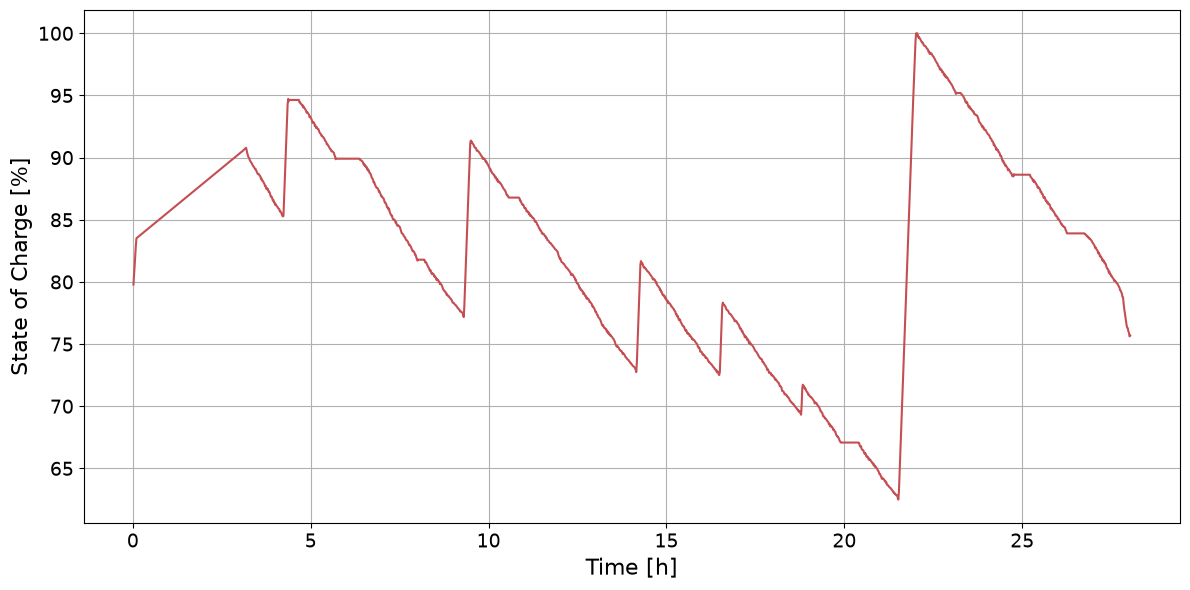

Saved: C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\FinalPlots\soc_over_time_1051.pdf


In [3]:
con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT 
        timestep_time, 
        vehicle_id, 
        vehicle_actualBatteryCapacity,
        vehicle_maximumBatteryCapacity,
        scenario, 
        seed, 
    FROM multirun_battery_aggregated
    WHERE scenario = 'summer' AND seed = 65 AND vehicle_id = 'bus_1051'
""").fetchdf()
con.close()

print(df.head())

df["soc"] = df["vehicle_actualBatteryCapacity"] / df["vehicle_maximumBatteryCapacity"] * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df["timestep_time"] / 3600,  # Convert seconds to hours
    df["soc"],
    color=PALETTE[3],
)

ax.set_xlabel("Time [h]",  fontsize = 16)
ax.set_ylabel("State of Charge [%]", fontsize = 16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.grid(True)

fig.tight_layout()

fig.savefig(
    OUTPUT_PATH / "soc_over_time_1051.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(f"Saved: {OUTPUT_PATH / 'soc_over_time_1051.pdf'}")

### Delay over Time

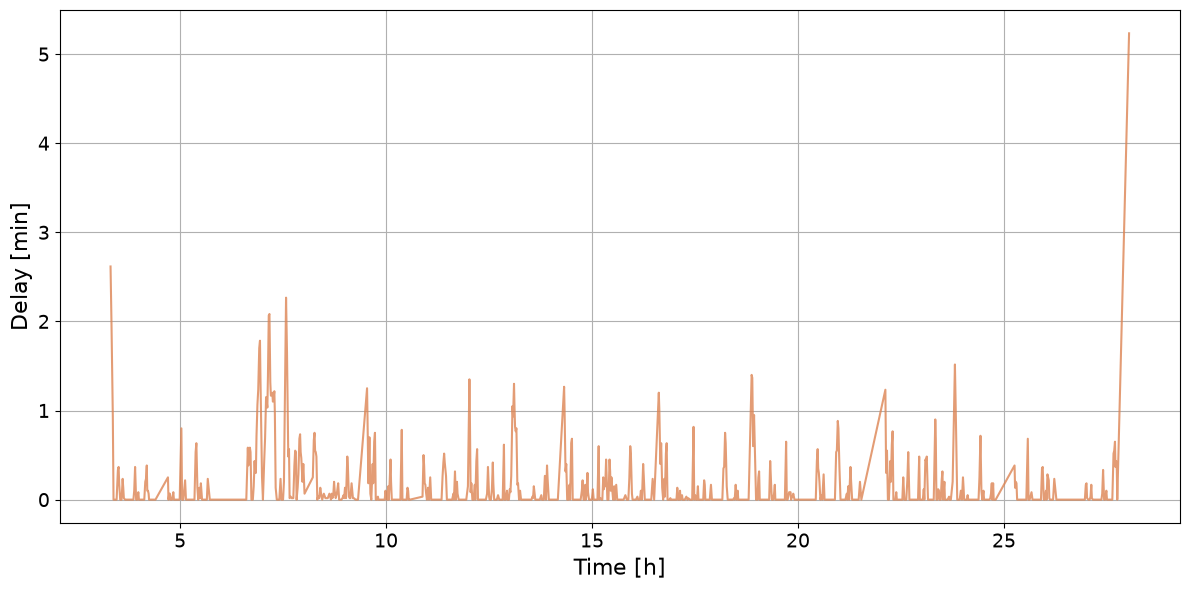

Saved: C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\FinalPlots\delay_over_time_1051.pdf


In [5]:
# 1051 Validation - Delay over Time
con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT 
        stopinfo_delay,
        stopinfo_started, 
        stopinfo_id, 
        scenario, 
        seed, 
    FROM multirun_stopinfo
    WHERE scenario = 'summer' AND seed = 65 AND stopinfo_id = 'bus_1051'
""").fetchdf()
con.close()

# Drop leading rows with stopinfo_delay == 0, up to the first non-zero value
nonzero_idx = df.index[df["stopinfo_delay"] != 0]
if len(nonzero_idx) > 0:
    df = df.loc[nonzero_idx[0]:].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df["stopinfo_started"] / 3600,  # Convert seconds to hours
    df["stopinfo_delay"] / 60,
    #linestyle=":",
    alpha=0.8,
    color=PALETTE[1],
)
"""
ax.scatter(
    df["stopinfo_started"] / 3600,  # Convert seconds to hours
    df["stopinfo_delay"],
    color=PALETTE[0],
)"""
ax.set_xlabel("Time [h]")
ax.set_ylabel("Delay [s]")
ax.set_xlabel("Time [h]",  fontsize = 16)
ax.set_ylabel("Delay [min]", fontsize = 16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.grid(True)

fig.tight_layout()

fig.savefig(
    OUTPUT_PATH / "delay_over_time_1051.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(f"Saved: {OUTPUT_PATH / 'delay_over_time_1051.pdf'}")

### Charging Events and total energy charged

Solution sets 15 charging events  
21 stops at charging stations  
10 charging events with energy charged

In [10]:
con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT
        chargingEvent_chargingBegin,
        chargingEvent_chargingEnd,
        chargingEvent_chargingStationId,
        chargingEvent_totalEnergyChargedIntoVehicle,
        scenario, 
        seed
    FROM multirun_chargingstations
    WHERE scenario = 'summer' 
    AND seed = 65 
    AND chargingEvent_vehicle = 'bus_1051'
    ORDER by chargingEvent_chargingBegin
""").fetchdf()
con.close()

df["chargingEvent_duration"] = df["chargingEvent_chargingEnd"] - df["chargingEvent_chargingBegin"]

print(df.describe())
print("-" * 50)
print(df.to_string())
print("-" * 50)
print(df.shape)
print("-" * 50)
print(f'Total energy charged: {df["chargingEvent_totalEnergyChargedIntoVehicle"].sum() / 1000}')
print("-" * 50)
print(f'Number of unique stations: {df["chargingEvent_chargingStationId"].nunique()}')

       chargingEvent_chargingBegin  chargingEvent_chargingEnd  \
count                    22.000000                  22.000000   
mean                  53473.272727               54184.545455   
std                   28089.464231               27181.824140   
min                     131.000000               11535.000000   
25%                   29959.250000               30142.000000   
50%                   53118.000000               53342.500000   
75%                   76045.500000               77495.000000   
max                   99900.000000               99919.000000   

       chargingEvent_totalEnergyChargedIntoVehicle  seed  \
count                                    22.000000  22.0   
mean                                  12337.707273  65.0   
std                                   25955.548058   0.0   
min                                       0.000000  65.0   
25%                                       0.000000  65.0   
50%                                       0.000000  65

### Energy Used and Regenerated

In [21]:
con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT
        tripinfo_id,
        battery_totalEnergyRegenerated,
        battery_totalEnergyConsumed,
        tripinfo_routeLength,
        scenario, 
        seed
    FROM multirun_tripinfo
    WHERE scenario = 'summer' 
    AND seed = 65 
    AND tripinfo_id = 'bus_1051'
""").fetchdf()
con.close()

df["energy_efficiency"] = (df["battery_totalEnergyConsumed"] - df["battery_totalEnergyRegenerated"]) / df["tripinfo_routeLength"]

print(df.to_string())
print("-" * 50)
print(f'Total energy consumed: {df["battery_totalEnergyConsumed"] / 1000}')
print("-" * 50)
print(f'Total energy regenrated: {df["battery_totalEnergyRegenerated"] / 1000}')
print("-" * 50)
print(f'Energy efficiency:: {df["energy_efficiency"]}')

  tripinfo_id  battery_totalEnergyRegenerated  battery_totalEnergyConsumed  tripinfo_routeLength scenario  seed  energy_efficiency
0    bus_1051                        374094.1                    658465.15             349912.57   summer    65           0.812692
--------------------------------------------------
Total energy consumed: 0    658.46515
Name: battery_totalEnergyConsumed, dtype: float64
--------------------------------------------------
Total energy regenrated: 0    374.0941
Name: battery_totalEnergyRegenerated, dtype: float64
--------------------------------------------------
Energy efficiency:: 0    0.812692
Name: energy_efficiency, dtype: float64


### Generate Route for Single Bus